<a href="https://colab.research.google.com/github/Abishekabi19/ML-and-DL-Project/blob/main/Studeent_academic_performance/Student_academic_perfomns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project title
AI Based Student Performance Prediction System

Problem statement

Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention.

Objective

To build a machine learning model that predicts whether a student will perform well or poorly based on multiple factors and provide insights for improvement.

Dataset

Student academic dataset containing
Attendance percentage, Internal assessment marks, Previous semester grades, Study hours, Participation in activities, Socio economic indicators. You can use a public dataset or create a realistic one.

Technologies used

Python,
Pandas,
NumPy,
Matplotlib and Seaborn,
Scikit learn,
Jupyter Notebook.

Workflow

1. Data understanding and problem definition
2. Data cleaning and handling missing values
3. Exploratory data analysis
4. Feature selection and encoding
5. Train test split
6. Model building using Logistic Regression Random Forest
7. Model evaluation using accuracy precision recall and confusion matrix
8. Result interpretation and insights
9. Conclusion and future scope.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ai_student_performance_dataset_200k (2).csv')
df

,student_id,attendance_percentage,internal_assessment_marks,previous_semester_gpa,study_hours_per_week,activity_participation_score,family_income_level,parent_education_level,internet_access
0,1,68.73,14.13,9.11,1.1,7,Low,Secondary,No
1,2,97.54,22.93,4.53,13.0,10,High,Secondary,Yes
2,3,86.60,4.96,2.42,56.4,10,Low,Graduate,No
3,4,79.93,22.34,9.36,27.2,5,Low,Primary,Yes
4,5,57.80,10.15,5.49,8.2,4,High,Graduate,Yes
...,...,...,...,...,...,...,...,...,...
199995,199996,81.11,37.51,7.38,33.5,9,Medium,Primary,Yes
199996,199997,81.46,13.63,5.83,7.5,8,High,Graduate,Yes
199997,199998,59.61,28.78,7.70,58.0,1,High,Primary,No
199998,199999,82.65,44.67,9.65,47.0,8,Medium,Primary,Yes


In [ ]:
import pandas as pd

# Function to assign grade based on GPA
def assign_grade(gpa):
    if gpa >= 9.0:
        return "O"
    elif gpa >= 8.0:
        return "A+"
    elif gpa >= 7.0:
        return "A"
    elif gpa >= 6.0:
        return "B+"
    elif gpa >= 5.0:
        return "B"
    elif gpa >= 4.0:
        return "C"
    else:
        return "F"

# Add grade column
df["grade"] = df["previous_semester_gpa"].apply(assign_grade)


In [ ]:
df

,student_id,attendance_percentage,internal_assessment_marks,previous_semester_gpa,study_hours_per_week,activity_participation_score,family_income_level,parent_education_level,internet_access,grade
0,1,68.73,14.13,9.11,1.1,7,Low,Secondary,No,O
1,2,97.54,22.93,4.53,13.0,10,High,Secondary,Yes,C
2,3,86.60,4.96,2.42,56.4,10,Low,Graduate,No,F
3,4,79.93,22.34,9.36,27.2,5,Low,Primary,Yes,O
4,5,57.80,10.15,5.49,8.2,4,High,Graduate,Yes,B
...,...,...,...,...,...,...,...,...,...,...
199995,199996,81.11,37.51,7.38,33.5,9,Medium,Primary,Yes,A
199996,199997,81.46,13.63,5.83,7.5,8,High,Graduate,Yes,B
199997,199998,59.61,28.78,7.70,58.0,1,High,Primary,No,A
199998,199999,82.65,44.67,9.65,47.0,8,Medium,Primary,Yes,O


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   student_id                    200000 non-null  int64  
 1   attendance_percentage         200000 non-null  float64
 2   internal_assessment_marks     200000 non-null  float64
 3   previous_semester_gpa         200000 non-null  float64
 4   study_hours_per_week          200000 non-null  float64
 5   activity_participation_score  200000 non-null  int64  
 6   family_income_level           200000 non-null  object 
 7   parent_education_level        200000 non-null  object 
 8   internet_access               200000 non-null  object 
 9   grade                         200000 non-null  object 
dtypes: float64(4), int64(2), object(4)
memory usage: 15.3+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df['family_income_level'].unique())

['Low' 'High' 'Medium']


In [ ]:
df['family_income_level'].replace(['Low','Medium','High'],[0,1,2],inplace=True)

/tmp/ipython-input-295792.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['family_income_level'].replace(['Low','Medium','High'],[0,1,2],inplace=True)
/tmp/ipython-input-295792.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['family_income_level'].replace(['Low','Medium','High'],[0,1,2

In [ ]:
print(df['parent_education_level'].unique())

['Secondary' 'Graduate' 'Primary' 'Postgraduate']


In [ ]:
df['parent_education_level'].replace(['Primary','Secondary','Graduate','Postgraduate'],[1,2,3,4],inplace=True)

/tmp/ipython-input-3586001027.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['parent_education_level'].replace(['Primary','Secondary','Graduate','Postgraduate'],[1,2,3,4],inplace=True)
/tmp/ipython-input-3586001027.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['parent_education_leve

In [ ]:
print(df['grade'].unique())

['O' 'C' 'F' 'B' 'A+' 'B+' 'A']


In [ ]:
df['grade'].replace(['O', 'A+', 'A', 'B+', 'B', 'C', 'F'],[6,5,4,3,2,1,0],inplace=True)

/tmp/ipython-input-878751062.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['grade'].replace(['O', 'A+', 'A', 'B+', 'B', 'C', 'F'],[6,5,4,3,2,1,0],inplace=True)
/tmp/ipython-input-878751062.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['grade'].replace(['O', 'A+', 'A', 'B+', 'B', 'C

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['internet_access']=le.fit_transform(df['internet_access'])

In [ ]:
df

,student_id,attendance_percentage,internal_assessment_marks,previous_semester_gpa,study_hours_per_week,activity_participation_score,family_income_level,parent_education_level,internet_access,grade
0,1,68.73,14.13,9.11,1.1,7,0,2,0,6
1,2,97.54,22.93,4.53,13.0,10,2,2,1,1
2,3,86.60,4.96,2.42,56.4,10,0,3,0,0
3,4,79.93,22.34,9.36,27.2,5,0,1,1,6
4,5,57.80,10.15,5.49,8.2,4,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...
199995,199996,81.11,37.51,7.38,33.5,9,1,1,1,4
199996,199997,81.46,13.63,5.83,7.5,8,2,3,1,2
199997,199998,59.61,28.78,7.70,58.0,1,2,1,0,4
199998,199999,82.65,44.67,9.65,47.0,8,1,1,1,6


<Axes: >

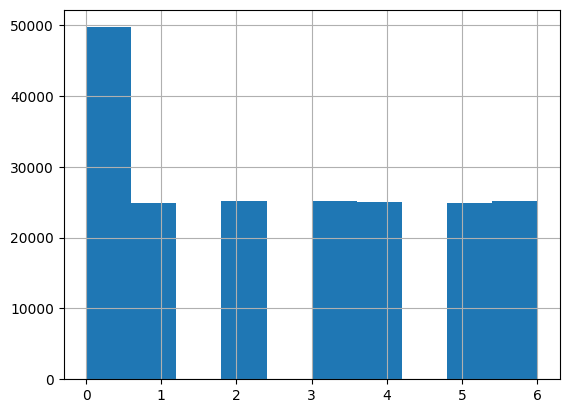

In [ ]:
df['grade'].hist()

In [ ]:
X=df.drop(columns=['grade'])
y=df['grade']

In [ ]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
X_smote,y_smote= smote.fit_resample(X,y)

df=pd.concat([pd.DataFrame(X_smote,columns=X.columns),
              pd.Series(y_smote,name=y.name)],axis=1)


<Axes: >

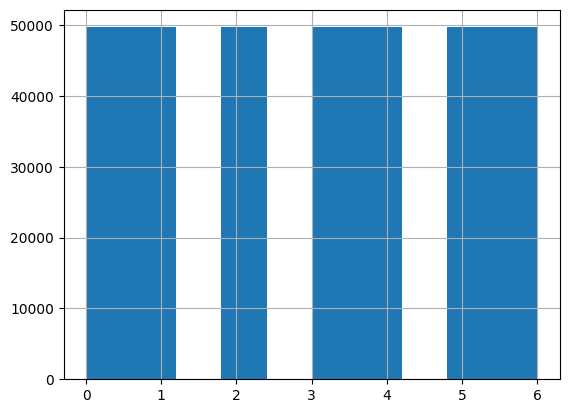

In [ ]:
df['grade'].hist()

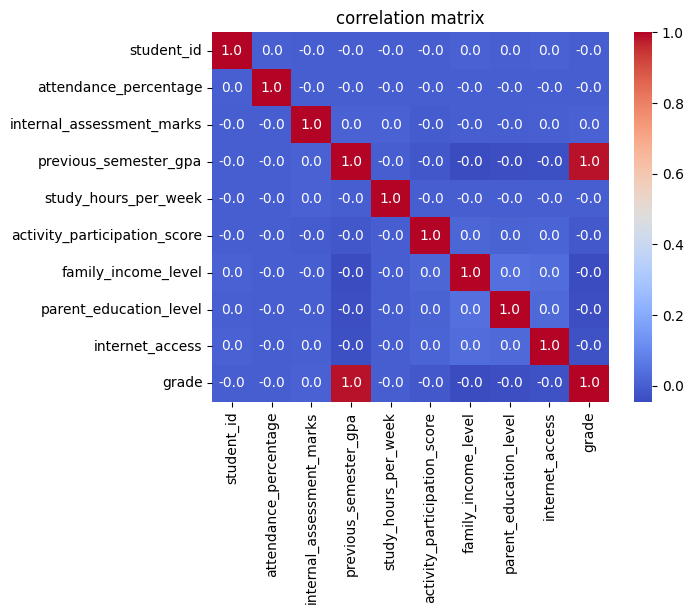

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

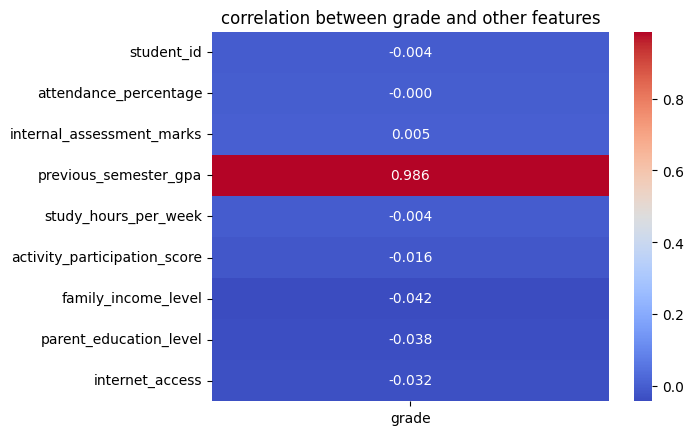

In [ ]:
grade_corr=df.corr()['grade']
grade_corr=grade_corr.drop('grade')

sns.heatmap(grade_corr.to_frame(),annot=True,fmt='0.3f',cmap='coolwarm',annot_kws={'size':10})
plt.title('correlation between grade and other features')
plt.show()

In [ ]:
df.drop(['attendance_percentage','student_id','study_hours_per_week'],axis=1,inplace=True)

<Axes: >

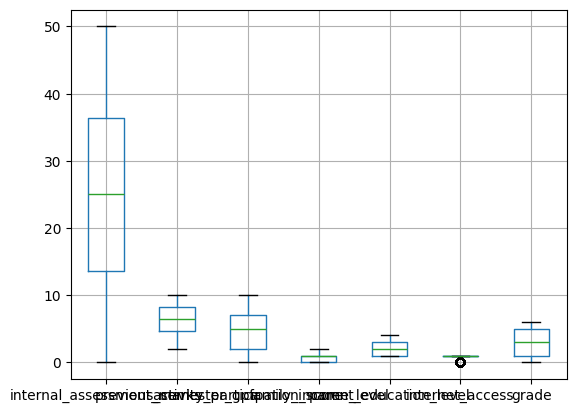

In [ ]:
df.boxplot()

In [ ]:
def remove_outlier(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df
df_cleaned=remove_outlier(df,exclude_column='grade')
df=df_cleaned


<Axes: >

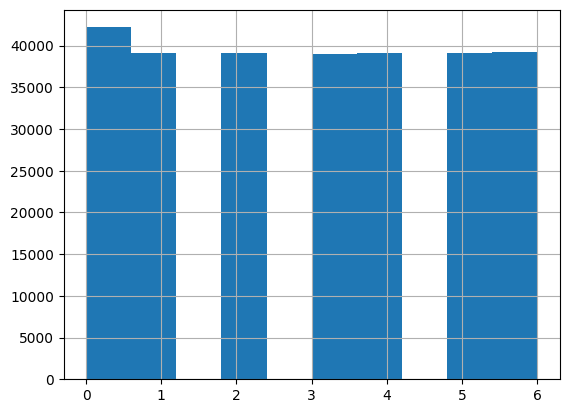

In [ ]:
df['grade'].hist()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

features=['internal_assessment_marks','previous_semester_gpa','activity_participation_score','family_income_level','parent_education_level','internet_access']

scaled=scaler.fit_transform(df[features])
df_scaled=pd.DataFrame(scaled,columns=features)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x=df_scaled
y=df['grade']

kf=KFold(n_splits=6,shuffle=True,random_state=42)

model=LogisticRegression()

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_pred,y_test)
  print(f'Accuracy:{acc}')

  if acc>best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_x_train=x_train
    best_y_train=y_train
    best_x_test=x_test
    best_y_test=y_test
    best_y_pred=y_pred

print(f'\n Best fold:{best_fold} with accuracy: {best_accuracy}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:0.9876893734151152


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:0.9901818418257873


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:0.9885560709176817


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:0.9911352897828254
Accuracy:0.9911569638909359

 Best fold:3 with accuracy: 0.9913088710201782


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model=LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9913088710201782

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

1.0

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

1.0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(800,activation='relu',input_shape=(6,)))
model.add(Dense(400,activation='relu'))
model.add(Dense(200,activation='relu'))
model.add(Dense(100,activation='relu'))
model.add(Dense(50,activation='relu'))
model.add(Dense(25,activation='relu'))
model.add(Dense(5,activation='relu'))
model.add(Dense(7,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_x_train,best_y_train,epochs=40,batch_size=32)

Epoch 1/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 72s 10ms/step - accuracy: 0.8210 - loss: 0.4610
Epoch 2/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.9611 - loss: 0.0976
Epoch 3/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.9663 - loss: 0.0836
Epoch 4/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - accuracy: 0.9712 - loss: 0.0707
Epoch 5/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.9744 - loss: 0.0649
Epoch 6/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.9758 - loss: 0.0614
Epoch 7/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.9773 - loss: 0.0569
Epoch 8/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.9800 - loss: 0.0504
Epoch 9/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - accuracy: 0.9800 - loss: 0.0498
Epoch 10/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - accuracy: 0.9817 - loss: 0.0456
Epoch 11/40
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 69s 10ms/step - accuracy: 0.9814 - loss: 0.0463
Epoch 12/40
7210/

In [ ]:
y_pred=model.predict(best_x_test)
print(y_pred)

loss,accuracy=model.evaluate(best_x_test,best_y_test)
print(f'Accuracy:{accuracy}')

1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
[[3.25827841e-06 9.99994338e-01 2.38710618e-06 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  6.23823313e-13 9.99999940e-01]
 [1.41973980e-03 9.83981013e-01 1.45992329e-02 ... 0.00000000e+00
  1.95886004e-29 1.25409754e-23]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.89208602e-10 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  7.38609401e-07 9.99999285e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.56997451e-10 1.00000000e+00]]
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9861 - loss: 0.0283
Accuracy:0.9894883036613464


In [ ]:
import pickle
with open('student_performance ML Model.pkl',"wb") as file:
  pickle.dump(model,file)

In [ ]:
with open('/content/student_performance ML Model.pkl',"rb") as file:
  load_model=pickle.load(file)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
best_x_test

,internal_assessment_marks,previous_semester_gpa,activity_participation_score,family_income_level,parent_education_level,internet_access
0,0.458600,0.316250,1.0,1.0,0.333333,0.0
1,0.446800,0.920000,0.5,0.0,0.000000,0.0
20,0.445000,0.372500,0.8,0.0,0.333333,0.0
28,0.555400,0.871250,0.9,0.5,0.000000,0.0
30,0.790200,0.387500,0.3,0.0,1.000000,0.0
...,...,...,...,...,...,...
276814,0.163007,0.961477,0.8,0.5,0.000000,0.0
276815,0.119274,0.936461,0.6,0.5,0.333333,0.0
276819,0.789061,0.913655,0.0,0.0,0.000000,0.0
276823,0.443340,0.901064,0.1,0.0,0.000000,0.0


In [ ]:
a=load_model.predict(np.array([[0.445000,0.372500,0.8,0.0,0.333333,0.0]]))
print(np.argmax(a))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
0


In [ ]:
b=load_model.predict(np.array([[0.789061,	0.913655,	0.0	,0.0,	0.000000,	0.0]]))
print(np.argmax(b))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
3


# Conclusion
This study presents a student performance prediction system using both Machine Learning (ML) and Deep Learning (DL) techniques on academic and behavioral data. Experimental results show that ML models outperform DL models for the given structured dataset. Among the ML approaches, the Decision Tree algorithm achieved the best performance due to its accuracy, interpretability, and ability to handle non-linear relationships. The final trained model was saved in Pickle format to support efficient deployment and reuse. The findings highlight that traditional ML models can be more effective than DL methods for student performance prediction in structured educational datasets.